# Sleep, Health and Lifestyle

In [1]:
#Librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Carga de datos
data = pd.read_csv('C:/Users/SERGIO/Desktop/Analisis Datos/Datos/Sleep_health_and_lifestyle_dataset.csv')

In [14]:
#Primera visualización
#Visualizando los datos
data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [15]:
#Información general
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [16]:
#Descripción estadística general de las variables numéricas
data.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


## Descripción General de la Población

### Distribución por género

In [17]:
#Cantidad de hombres y mujeres
data['Gender'].value_counts()

Gender
Male      189
Female    185
Name: count, dtype: int64

### Distribución por edades

In [18]:
#Descripción estadística
data['Age'].describe()

count    374.000000
mean      42.184492
std        8.673133
min       27.000000
25%       35.250000
50%       43.000000
75%       50.000000
max       59.000000
Name: Age, dtype: float64

In [19]:
#Edades con más cantidad de participantes
data['Age'].value_counts().sort_values(ascending=False)[:10]

Age
43    34
44    30
37    20
38    20
50    20
31    18
32    17
53    17
59    16
39    15
Name: count, dtype: int64

([<matplotlib.axis.XTick at 0x17e4d0434d0>,
 [Text(27, 0, '27'),
  Text(30, 0, '30'),
  Text(33, 0, '33'),
  Text(36, 0, '36'),
  Text(39, 0, '39'),
  Text(42, 0, '42'),
  Text(45, 0, '45'),
  Text(48, 0, '48'),
  Text(51, 0, '51'),
  Text(54, 0, '54'),
  Text(57, 0, '57'),
  Text(60, 0, '60')])

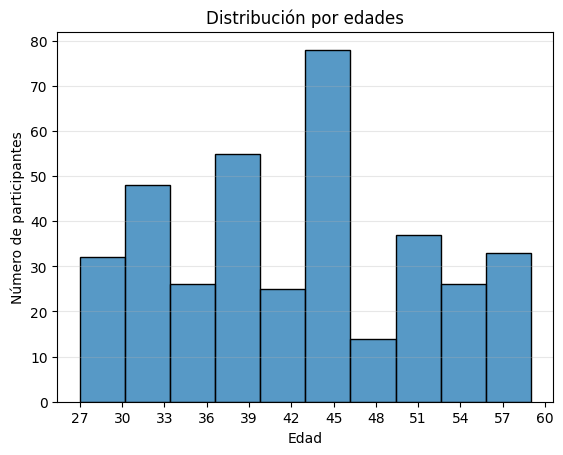

In [20]:
#Histograma de edades
sns.histplot(
    data = data['Age'],
    bins = 10
)

plt.grid(axis='y', alpha=0.3)
plt.title('Distribución por edades')
plt.xlabel('Edad')
plt.ylabel('Número de participantes')
plt.xticks(range(data['Age'].min(), data['Age'].max()+3, 3))

Text(0.5, 0, 'Edad')

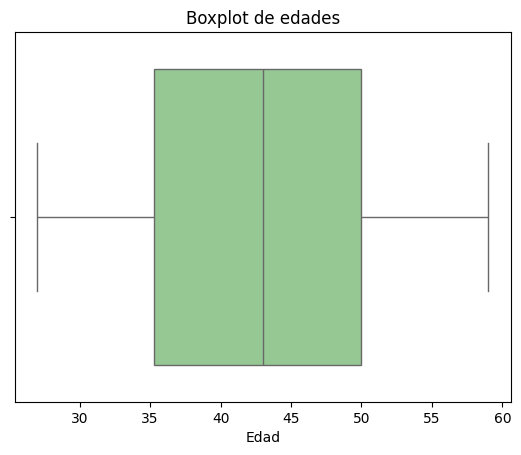

In [21]:
#Boxplot de edades
sns.boxplot(
    x = data['Age'],
    color = sns.color_palette("Greens")[2]
    
)

plt.title('Boxplot de edades')
plt.xlabel('Edad')

### Distribución por ocupaciones

In [22]:
#Tabla de ocupaciones
ocupaciones = data['Occupation'].value_counts().to_frame("Frecuencia")
ocupaciones['Porcentaje'] = (ocupaciones['Frecuencia'] / 374 * 100).round(2)
ocupaciones

,Frecuencia,Porcentaje
Occupation,,
Nurse,73,19.52
Doctor,71,18.98
Engineer,63,16.84
Lawyer,47,12.57
Teacher,40,10.70
Accountant,37,9.89
Salesperson,32,8.56
Scientist,4,1.07
Software Engineer,4,1.07


In [23]:
#Traducción al español
data['Occupation'] = data['Occupation'].replace({
    "Nurse": "Enfermería",
    "Doctor": "Doctor",
    "Engineer": "Ingeniero",
    "Lawyer": "Abogado",
    "Teacher": "Profesor",
    "Accountant": "Contador",
    "Salesperson": "Vendedor",
    "Scientist": "Científico",
    "Software Engineer": "Ingeniero de Software",
    "Sales Representative": "Representante de ventas",
    "Manager": "Gerente"
})

data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Ingeniero de Software,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Representante de ventas,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Representante de ventas,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


[Text(1, 0, '73'),
 Text(1, 0, '71'),
 Text(1, 0, '63'),
 Text(1, 0, '47'),
 Text(1, 0, '40'),
 Text(1, 0, '37'),
 Text(1, 0, '32'),
 Text(1, 0, '4'),
 Text(1, 0, '4'),
 Text(1, 0, '2'),
 Text(1, 0, '1')]

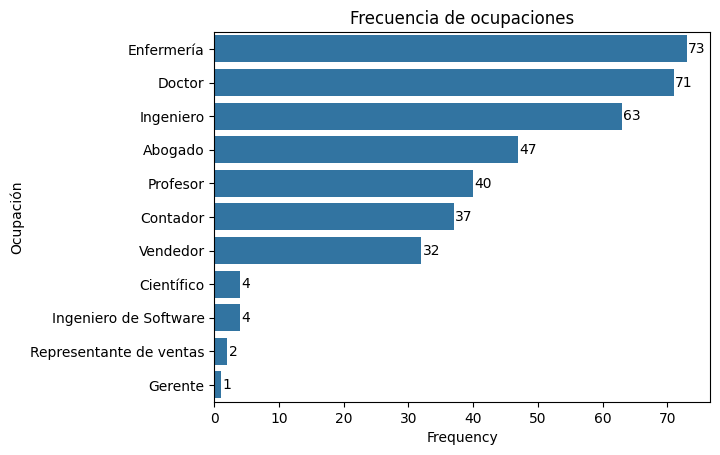

In [24]:
#Gráfico de barras de ocupaciones
graf_occ = sns.countplot(
    y = data['Occupation'],
    order = data["Occupation"].value_counts().index
)

plt.title('Frecuencia de ocupaciones')
plt.xlabel('Frequency')
plt.ylabel('Ocupación')
graf_occ.bar_label(graf_occ.containers[0], padding=1)

### Distribución del IMC

In [25]:
#Cantidad de datos de cada categoría
data['BMI Category'].value_counts().sort_values(ascending=False)

BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64

In [26]:
#Traducción
data['BMI Category'] = data['BMI Category'].replace({
    "Normal": "Peso Normal",
    "Normal Weight": "Peso Normal",
    "Overweight": "Sobrepeso",
    "Obese": "Obesidad"
})

data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Ingeniero de Software,6.1,6,42,6,Sobrepeso,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Peso Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Peso Normal,125/80,75,10000,NaN
3,4,Male,28,Representante de ventas,5.9,4,30,8,Obesidad,140/90,85,3000,Sleep Apnea
4,5,Male,28,Representante de ventas,5.9,4,30,8,Obesidad,140/90,85,3000,Sleep Apnea


In [27]:
#Frecuencia de cada categoría de BMI
imc = data['BMI Category'].value_counts().sort_values(ascending=False).to_frame()
imc['Porcentaje'] = (imc['count'] / 374 * 100).round(2)
imc

,count,Porcentaje
BMI Category,,
Peso Normal,216,57.75
Sobrepeso,148,39.57
Obesidad,10,2.67


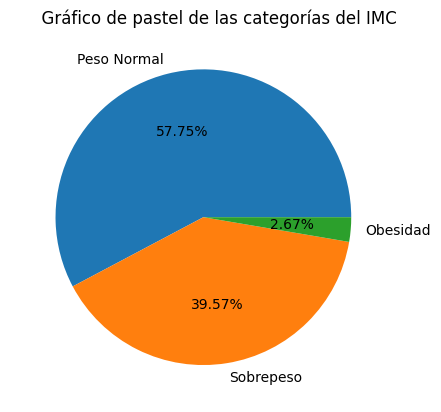

In [28]:
#Gráfico de pastel
plt.pie(
    imc['count'],
    labels=imc.index,
    autopct='%1.2f%%'
)

plt.title('      Gráfico de pastel de las categorías del IMC')
plt.show()

## Calidad del sueño

In [29]:
#Distribución de la calidad del sueño
calidad = data['Quality of Sleep'].value_counts().sort_index().to_frame()
calidad['Porcentaje'] = (calidad['count'] / 374 * 100).round(2)
calidad

,count,Porcentaje
Quality of Sleep,,
4,5,1.34
5,7,1.87
6,105,28.07
7,77,20.59
8,109,29.14
9,71,18.98


### Relación con el género

In [30]:
#Traducción
data['Gender'] = data['Gender'].replace({
    "Female": "Femenino",
    "Male": "Masculino"
})

data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Masculino,27,Ingeniero de Software,6.1,6,42,6,Sobrepeso,126/83,77,4200,NaN
1,2,Masculino,28,Doctor,6.2,6,60,8,Peso Normal,125/80,75,10000,NaN
2,3,Masculino,28,Doctor,6.2,6,60,8,Peso Normal,125/80,75,10000,NaN
3,4,Masculino,28,Representante de ventas,5.9,4,30,8,Obesidad,140/90,85,3000,Sleep Apnea
4,5,Masculino,28,Representante de ventas,5.9,4,30,8,Obesidad,140/90,85,3000,Sleep Apnea


In [31]:
#Relación de la calidad del sueño y el género
genero_calidad = data['Quality of Sleep'].groupby(data['Gender']).value_counts().to_frame()
genero_calidad['Porcentaje'] = (genero_calidad['count'] * 100 / 374).round(2)
genero_calidad

count  Porcentaje
Gender    Quality of Sleep                   
Femenino  9                    69       18.45
          6                    37        9.89
          7                    37        9.89
          8                    36        9.63
          5                     4        1.07
          4                     2        0.53
Masculino 8                    73       19.52
          6                    68       18.18
          7                    40       10.70
          4                     3        0.80
          5                     3        0.80
          9                     2        0.53

In [32]:
#Descripción estadísitca
data['Quality of Sleep'].groupby(data['Gender']).describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Femenino,185.0,7.66,1.28,4.0,7.0,8.0,9.0,9.0
Masculino,189.0,6.97,1.00,4.0,6.0,7.0,8.0,9.0


Text(0.5, 0, 'Género')

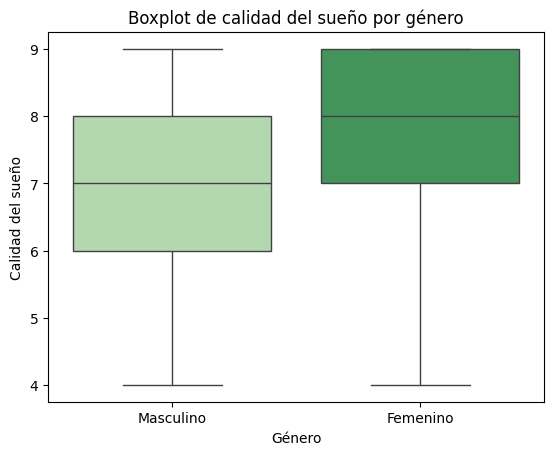

In [55]:
#Boxplot
sns.boxplot(
    data = data,
    x = 'Gender',
    y = 'Quality of Sleep',
    hue = 'Gender',
    palette = 'Greens'
)

plt.title('Boxplot de calidad del sueño por género')
plt.ylabel('Calidad del sueño')
plt.xlabel('Género')

### Calidad del sueño entre ocupaciones

In [34]:
#Descripción estadística
calidad_ocupacion = data['Quality of Sleep'].groupby(data['Occupation']).agg(['count', 'mean', 'min', 'median', 'max']).round(2).sort_values(by= 'mean', ascending=False)

calidad_ocupacion

,count,mean,min,median,max
Occupation,,,,,
Ingeniero,63,8.41,5,9.0,9
Contador,37,7.89,7,8.0,9
Abogado,47,7.89,7,8.0,8
Enfermería,73,7.37,5,6.0,9
Gerente,1,7.00,7,7.0,7
Profesor,40,6.98,5,7.0,8
Doctor,71,6.65,6,7.0,9
Ingeniero de Software,4,6.50,4,7.0,8
Vendedor,32,6.00,6,6.0,6


([<matplotlib.axis.XTick at 0x17e4d1db250>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9')])

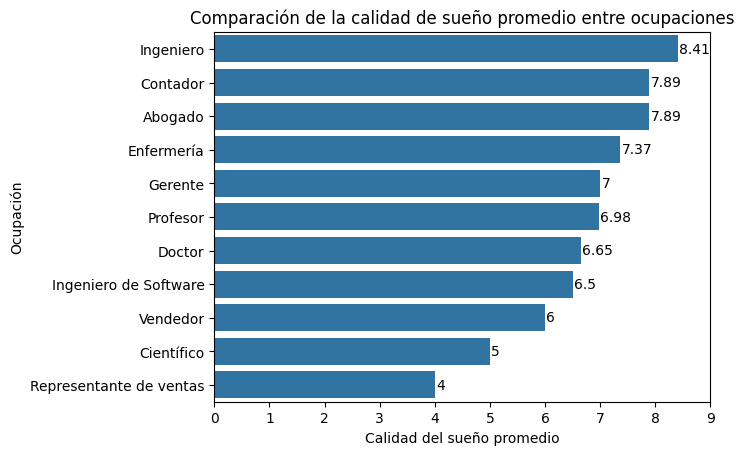

In [35]:
#Gráfico de barras
graf_calidad_occ = sns.barplot(
    data = calidad_ocupacion,
    x = 'mean',
    y = 'Occupation'
)

graf_calidad_occ.bar_label(graf_calidad_occ.containers[0], padding = 1)
plt.title('Comparación de la calidad de sueño promedio entre ocupaciones')
plt.ylabel('Ocupación')
plt.xlabel('Calidad del sueño promedio')
plt.xticks(range(0, 10))

### Calidad del sueño y horas dormidas

In [36]:
#Horas de sueño y descripción estadística
data['Sleep Duration'].describe()

count    374.000000
mean       7.132086
std        0.795657
min        5.800000
25%        6.400000
50%        7.200000
75%        7.800000
max        8.500000
Name: Sleep Duration, dtype: float64

In [37]:
#Correlación entre horas dormidas y calidad del sueño
data[['Sleep Duration', 'Quality of Sleep']].corr().round(2)

,Sleep Duration,Quality of Sleep
Sleep Duration,1.00,0.88
Quality of Sleep,0.88,1.00


Text(0, 0.5, 'Calidad del sueño')

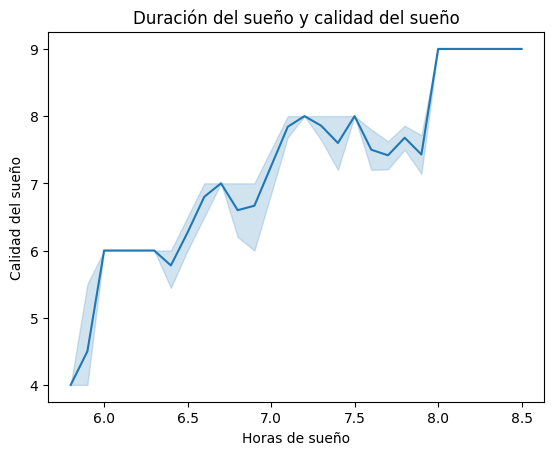

In [38]:
#Gráfico de dispersión
sns.lineplot(
    data = data,
    x = 'Sleep Duration',
    y = 'Quality of Sleep'
)

plt.title("Duración del sueño y calidad del sueño")
plt.xlabel("Horas de sueño")
plt.ylabel("Calidad del sueño")

### Calidad del sueño y estrés

In [39]:
#Correlación entre la calidad del sueño y el estrés
data[['Quality of Sleep', 'Stress Level']].corr().round(2)

,Quality of Sleep,Stress Level
Quality of Sleep,1.0,-0.9
Stress Level,-0.9,1.0


Text(0, 0.5, 'Calidad del sueño')

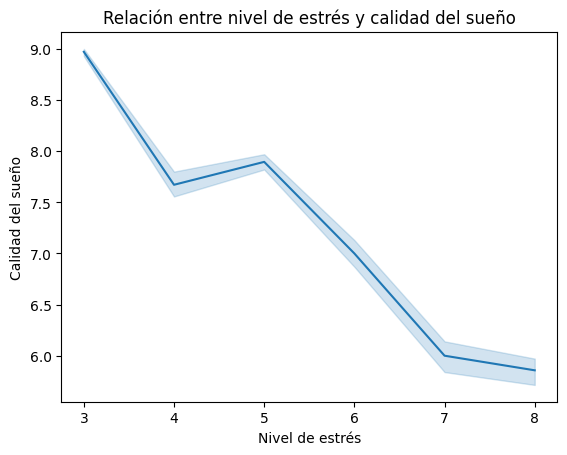

In [40]:
#Gráfica de líneas
sns.lineplot(
    data = data,
    x = 'Stress Level',
    y = 'Quality of Sleep'
)

plt.title('Relación entre nivel de estrés y calidad del sueño')
plt.xlabel('Nivel de estrés')
plt.ylabel('Calidad del sueño')

In [41]:
#Ocupaciones con mayor nivel de estrés
occ_estres = data['Stress Level'].groupby(data['Occupation']).agg(['count', 'mean', 'min', 'median','max']).round(2).sort_values(by = 'mean', ascending=False)
occ_estres

,count,mean,min,median,max
Occupation,,,,,
Representante de ventas,2,8.00,8,8.0,8
Vendedor,32,7.00,7,7.0,7
Científico,4,7.00,6,7.0,8
Doctor,71,6.73,3,6.0,8
Ingeniero de Software,4,6.00,5,5.5,8
Enfermería,73,5.55,3,6.0,8
Abogado,47,5.06,5,5.0,6
Gerente,1,5.00,5,5.0,5
Contador,37,4.59,3,4.0,7


Text(0, 0.5, 'Ocupación')

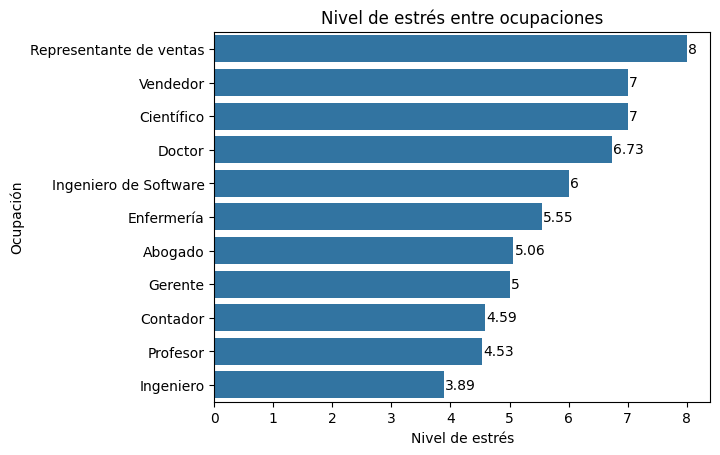

In [42]:
#Gráfico de nivel de estrés entre ocupaciones
graf_stress_occ = sns.barplot(
    data = occ_estres,
    x = 'mean',
    y = 'Occupation'
)

graf_stress_occ.bar_label(graf_stress_occ.containers[0], padding = 1)
plt.title('Nivel de estrés entre ocupaciones')
plt.xlabel('Nivel de estrés')
plt.ylabel('Ocupación')

## Trastornos del sueño

### Trastorno del sueño más frecuente

In [43]:
#Conteo
data["Sleep Disorder"].value_counts(dropna=False)

Sleep Disorder
NaN            219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [44]:
#Cambiando valores NA por "Sin trastorno"

data['Sleep Disorder'] = (data['Sleep Disorder'].fillna('Sin trastorno').replace({
    'Insomnia': 'Insomnio',
    'Sleep Apnea': 'Apnea del sueño'
    })
)
data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Masculino,27,Ingeniero de Software,6.1,6,42,6,Sobrepeso,126/83,77,4200,Sin trastorno
1,2,Masculino,28,Doctor,6.2,6,60,8,Peso Normal,125/80,75,10000,Sin trastorno
2,3,Masculino,28,Doctor,6.2,6,60,8,Peso Normal,125/80,75,10000,Sin trastorno
3,4,Masculino,28,Representante de ventas,5.9,4,30,8,Obesidad,140/90,85,3000,Apnea del sueño
4,5,Masculino,28,Representante de ventas,5.9,4,30,8,Obesidad,140/90,85,3000,Apnea del sueño


In [45]:
#Frecuencia de cada trastorno
frec_trastornos = data['Sleep Disorder'].value_counts().to_frame()
frec_trastornos['Porcentaje'] = (frec_trastornos['count'] * 100 / 374).round(2)
frec_trastornos

,count,Porcentaje
Sleep Disorder,,
Sin trastorno,219,58.56
Apnea del sueño,78,20.86
Insomnio,77,20.59


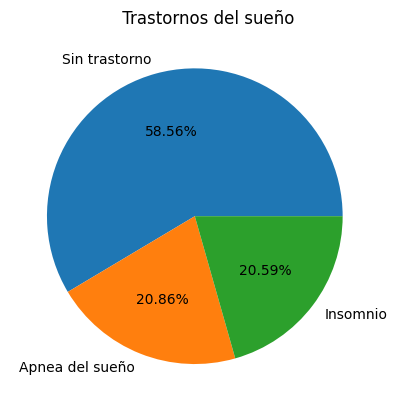

In [46]:
#Gráfico de pastel
plt.pie(
    frec_trastornos['count'],
    labels=frec_trastornos.index,
    autopct='%1.2f%%'
)

plt.title('     Trastornos del sueño')
plt.show()

### Trastornos del sueño e IMC

In [47]:
#Tabla de trastornos del sueño por IMC
pd.crosstab(
    data["BMI Category"],
    data["Sleep Disorder"]
)

Sleep Disorder,Apnea del sueño,Insomnio,Sin trastorno
BMI Category,,,
Obesidad,6,4,0
Peso Normal,7,9,200
Sobrepeso,65,64,19


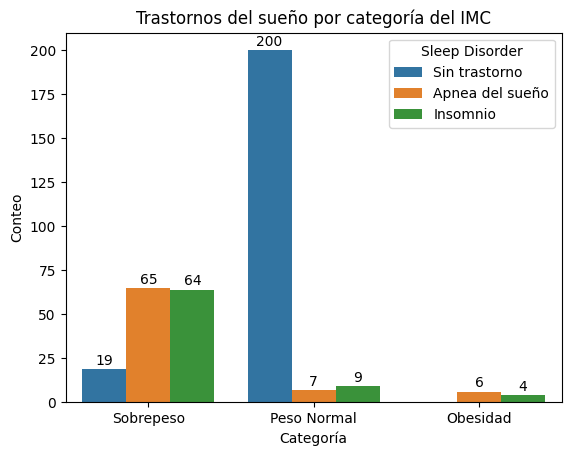

In [48]:
#Gráfica de barras
graf_tras_imc = sns.countplot(
    data = data,
    x = 'BMI Category',
    hue = 'Sleep Disorder'
)

plt.title('Trastornos del sueño por categoría del IMC')
plt.xlabel('Categoría')
plt.ylabel('Conteo')

for container in graf_tras_imc.containers:
    graf_tras_imc.bar_label(container, padding = 1)

### Relación entre los trastornos del sueño y la calidad

In [49]:
#Descripción estadíscita de los trastornos del sueño y la calidad del sueño
data['Quality of Sleep'].groupby(data['Sleep Disorder']).agg(['count', 'mean', 'min', 'median', 'max'])

,count,mean,min,median,max
Sleep Disorder,,,,,
Apnea del sueño,78,7.205128,4,6.0,9
Insomnio,77,6.532468,4,7.0,9
Sin trastorno,219,7.625571,6,8.0,9


Text(0, 0.5, 'Calidad del sueño')

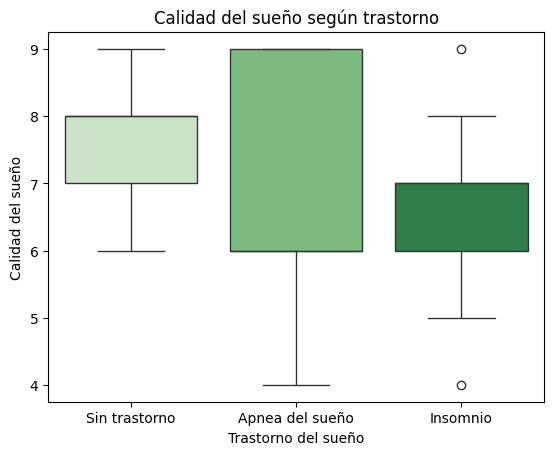

In [56]:
sns.boxplot(
    data=data,
    x = 'Sleep Disorder',
    y = 'Quality of Sleep',
    hue = 'Sleep Disorder',
    palette = 'Greens'
)

plt.title('Calidad del sueño según trastorno')
plt.xlabel('Trastorno del sueño')
plt.ylabel('Calidad del sueño')

### Características de las personas sin trastornos del sueño

In [51]:
#Creación de una nueva variable
data["Tiene_Trastorno"] = data["Sleep Disorder"].apply(lambda x: "Sí" if x != "Sin trastorno" else "No")
data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Tiene_Trastorno
0,1,Masculino,27,Ingeniero de Software,6.1,6,42,6,Sobrepeso,126/83,77,4200,Sin trastorno,No
1,2,Masculino,28,Doctor,6.2,6,60,8,Peso Normal,125/80,75,10000,Sin trastorno,No
2,3,Masculino,28,Doctor,6.2,6,60,8,Peso Normal,125/80,75,10000,Sin trastorno,No
3,4,Masculino,28,Representante de ventas,5.9,4,30,8,Obesidad,140/90,85,3000,Apnea del sueño,Sí
4,5,Masculino,28,Representante de ventas,5.9,4,30,8,Obesidad,140/90,85,3000,Apnea del sueño,Sí


In [52]:
#Cantidad de personas con y sin trastornos
data['Tiene_Trastorno'].value_counts()

Tiene_Trastorno
No    219
Sí    155
Name: count, dtype: int64

In [53]:
#Media del nivel de estrés, horas de sueño, nivel de actividad, cantidad de pasos diarios y frecuencia cardiaca para personas con y sin trastornos del sueño
data.groupby('Tiene_Trastorno')[['Stress Level', 'Sleep Duration', 'Physical Activity Level', 'Daily Steps', 'Heart Rate']].mean().round(2)

,Stress Level,Sleep Duration,Physical Activity Level,Daily Steps,Heart Rate
Tiene_Trastorno,,,,,
No,5.11,7.36,57.95,6852.97,69.02
Sí,5.77,6.81,60.90,6765.81,71.79


In [54]:
#Mediana del nivel de estrés, horas de sueño, nivel de actividad, cantidad de pasos diarios y frecuencia cardiaca para personas con y sin trastornos del sueño
data.groupby('Tiene_Trastorno')[['Stress Level', 'Sleep Duration', 'Physical Activity Level', 'Daily Steps', 'Heart Rate']].median().round(2)

,Stress Level,Sleep Duration,Physical Activity Level,Daily Steps,Heart Rate
Tiene_Trastorno,,,,,
No,5.0,7.4,60.0,7000.0,70.0
Sí,7.0,6.5,45.0,6000.0,72.0
